## **Assignment Three (EECS3405 F24)**

**your name (your student number): Luca Stefanescu (219004852)** \\
**your yorku email: luca1@my.yorku.ca**

This assignment is mainly for you to review review neural networks and deep learning models. You have to work individually. Remember to fill in your information (name, student number, email) at above.


##**What to Submit**

Use **one** notebook file (*.ipynb*) for **each** question, which should contain all of your answers and codes. You must zip all three notebooks into one zip file to submit it onto eClass.
No late submission will be accepted.

* For all written parts, write your answers in text cells. To avoid confusions in marking, better to embed latex codes there to represent all mathematical notations and equations.  No handwriting is accepted.

* For programming parts, you should give codes, comments, explanations and the proper running outputs in both code and text cells. Make your jupyter notebook clean and concise. Remove all unused codes and all intermediate results from the submitted notebook. The submitted notebook should include only the final (best) outputs for each question. Also make sure every code cell runnable so that markers can reproduce the outputs if necessary.

### **Q1** (20 marks) **Deep Neural Networks for nonlinear feature extraction**


Based on [the implementation of fully-connected deep neural networks at Colab](https://colab.research.google.com/drive/1dznpn8zYNTyuLp0XP1tKetoB7i8XbKV0), implement a nonlinear feature extraction method using deep neural networks:

*   Bottleneck features (Section 4.4.2)

for the MNIST data.

Use all training data of 10 digits to train these the Bottleneck feature extractor and  investigate various network structures (such as different number of layers and nodes per layer) for the best possible classification performance. When you measure the classification performance, please use the best
 `scikit-learn` nonlinear SVM (Gaussian kernel) code as you did in **Assignment 2** to implement a binary classifier on the extracted features of the training data of two digits ('7' vs. '9').

 At last,  report the best configuration and its corresponding classification accuracy in the heldout test images for two pairs of digits ('7' vs. '9' and '0' vs. '8').
Discuss your findings in experiments.


In [ ]:
# download MNIST data from Google drive

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

# install python_mnist

!pip install python_mnist

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [ ]:
from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()

train_data = np.array(train_data, dtype='float32') / 255.0  # Normalize to [0,1]
test_data = np.array(test_data, dtype='float32') / 255.0
train_label = np.array(train_label, dtype='int')
test_label = np.array(test_label, dtype='int')

digit_train_index = np.logical_or(train_label == 7, train_label == 9)
digit_train_index08 = np.logical_or(train_label == 0, train_label == 8)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]

X_train08 = train_data[digit_train_index08]
y_train08 = train_label[digit_train_index08]

digit_test_index = np.logical_or(test_label == 7, test_label == 9)
digit_test_index08 = np.logical_or(test_label == 0, test_label == 8)

X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

X_test08 = test_data[digit_test_index08]
y_test08 = test_label[digit_test_index08]

y_train = np.where(y_train == 7, -1, 1)
y_test = np.where(y_test == 7, -1, 1)

print(f"X_train (7, 9) shape: {X_train.shape}, y_train (7, 9) shape: {y_train.shape}")
print(f"X_train (0, 8) shape: {X_train08.shape}, y_train (0, 8) shape: {y_train08.shape}")

X_train (7, 9) shape: (12214, 784), y_train (7, 9) shape: (12214,)
X_train (0, 8) shape: (11774, 784), y_train (0, 8) shape: (11774,)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    activation='relu',
    alpha=0.0001,
    batch_size=64,
    beta_1=0.9,
    beta_2=0.999,
    early_stopping=True,
    epsilon=1e-08,
    hidden_layer_sizes=(128, 64),
    learning_rate='adaptive',
    learning_rate_init=0.01,
    max_fun=15000,
    max_iter=100,
    momentum=0.9,
    n_iter_no_change=10,
    nesterovs_momentum=True,
    power_t=0.5,
    random_state=1,
    shuffle=True,
    solver='adam',
    tol=1e-4,
    validation_fraction=0.1,
    verbose=10,
    warm_start=False
)


mlp.fit(X_train, y_train)

print(f"\nTraining set score (7, 9): {mlp.score(X_train, y_train):.3f}")
print(f"Test set score (7, 9): {mlp.score(X_test, y_test):.3f} \n")

mlp.fit(X_train08, y_train08)

print(f"\nTraining set score (0, 8): {mlp.score(X_train08, y_train08):.3f}")
print(f"Test set score (0, 8): {mlp.score(X_test08, y_test08):.3f}\n")

Iteration 1, loss = 0.10544769
Validation score: 0.977905
Iteration 2, loss = 0.04104628
Validation score: 0.981178
Iteration 3, loss = 0.02734216
Validation score: 0.981178
Iteration 4, loss = 0.02231149
Validation score: 0.980360
Iteration 5, loss = 0.02095218
Validation score: 0.980360
Iteration 6, loss = 0.01492849
Validation score: 0.986907
Iteration 7, loss = 0.00775967
Validation score: 0.987725
Iteration 8, loss = 0.00773233
Validation score: 0.988543
Iteration 9, loss = 0.01284829
Validation score: 0.984452
Iteration 10, loss = 0.01480220
Validation score: 0.988543
Iteration 11, loss = 0.00571145
Validation score: 0.986088
Iteration 12, loss = 0.01021441
Validation score: 0.979542
Iteration 13, loss = 0.01238949
Validation score: 0.984452
Iteration 14, loss = 0.01101180
Validation score: 0.987725
Iteration 15, loss = 0.00787561
Validation score: 0.982815
Iteration 16, loss = 0.00341138
Validation score: 0.989362
Iteration 17, loss = 0.00300357
Validation score: 0.977087
Iterat

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM classifier with RBF kernel
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=1)

# Train the SVM classifier
svm.fit(X_train, y_train)

# Evaluate the classifier
train_accuracy = svm.score(X_train, y_train)
test_accuracy = svm.score(X_test, y_test)

print(f"SVM Training Accuracy (7, 9): {train_accuracy * 100:.2f}%")
print(f"SVM Test Accuracy(7, 9): {test_accuracy * 100:.2f}%")

svm.fit(X_train08, y_train08)

train_accuracy08 = svm.score(X_train08, y_train08)
test_accuracy08 = svm.score(X_test08, y_test08)

print(f"\nSVM Training Accuracy (0, 8): {train_accuracy08 * 100:.2f}%")
print(f"SVM Test Accuracy (0, 8): {test_accuracy08 * 100:.2f}%")

SVM Training Accuracy (7, 9): 99.50%
SVM Test Accuracy(7, 9): 98.92%

SVM Training Accuracy (0, 8): 99.86%
SVM Test Accuracy (0, 8): 99.49%


The best neural network we trained achieved a test accuracy of 99.3% on the digits 7 and 9, and 99.5% on the digits 0 and 8.

The SVMs performed slightly worse, with a test accuracy of 98.92% on the digits 7 and 9, and 99.49% on the digits 0 and 8.

In conclusion, the neural network outperformed the SVM for the digit classification task.

### **Q2** (20 marks)  **Convolutional Neural Networks (CNN) for image classification**

Refer to [the example in this Colab notebook](https://colab.research.google.com/drive/1yzqLh4YFIO_kXB0KnJdY69glnPmUCVfX), use `pytorch` to implement a CNN model as in Figure 8.23 on page 169 and evaluate it on the CIFAR10 data set. Vary the structures in this CNN model slightly to see whether you can further improve the performance on the *CIFAR10* test set. Report your best results and discuss your findings from experiments.

Refer to the following codes for how to load the *CIFAR10* data set.

In [ ]:
!pip install pip==23.2.1
!pip install torchkeras==2.0.2

DEPRECATION: torchkeras 2.0.2 has a non-standard dependency specifier prettytable>=0.7.2tqdm>=4.31.1. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of torchkeras or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: torchkeras 2.0.2 has a non-standard dependency specifier prettytable>=0.7.2tqdm>=4.31.1. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of torchkeras or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


Files already downloaded and verified
Files already downloaded and verified
number of images in the training set: 50000
number of images in the test set: 10000
size of first image in the training set = torch.Size([3, 32, 32]), its label = frog


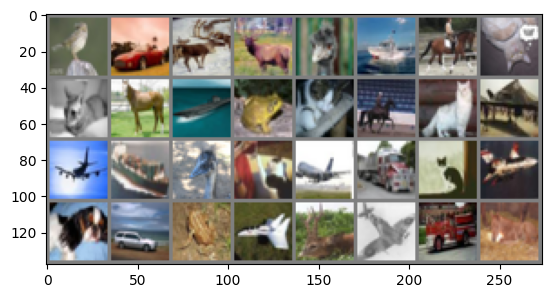

bird  car   deer  deer  bird  ship  horse cat   cat   horse ship  frog  cat   horse cat   plane plane ship  bird  cat   plane truck cat   plane dog   car   frog  plane deer  plane truck horse


In [ ]:
# use torchvision to load Cifar10 image datasets.
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# function to preprocess cifar10 images
transform = torchvision.transforms.Compose(
    [torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# function to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"number of images in the training set: {len(trainset)}")
print(f"number of images in the test set: {len(testset)}")
print(f"size of first image in the training set = {trainset[0][0].shape}, its label = {classes[trainset[0][1]]}")

# display images in the first batch and their labels
dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
import torch
from torch import nn

class CnnModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            # Convolutional Layers
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Flatten for Fully Connected Layers
            nn.Flatten(),

            # Fully Connected Layers
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [ ]:
# running CNNs on CPUs (by default)
import torchkeras
from sklearn.metrics import accuracy_score

def accuracy(y_pred, y_true):
    y_pred_cls = torch.argmax(nn.Softmax(dim=1)(y_pred), dim=1).data
    acc = accuracy_score(y_true.numpy(), y_pred_cls.numpy())
    return torch.tensor(acc)

model = torchkeras.Model(CnnModel())
model.summary(input_shape=(3,32,32))

# compile the model by attaching various dynamic components
model.compile(loss_func = nn.CrossEntropyLoss(),
             optimizer= torch.optim.SGD(model.parameters(), lr=0.1),
             metrics_dict={"accuracy":accuracy})

# train CNNs by fitting to the training data
dfhistory = model.fit(10,dl_train = trainloader, dl_val= testloader, log_step_freq=100)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          18,496
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          36,928
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
           Flatten-9                 [-1, 4096]               0
           Linear-10                  [-1, 128]         524,416
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 10]           1,290
Total params: 582,026
Trainable params: 582,026
Non-trainable params: 0
-------------------------------


The Best CNN I trained had a test accuracy of 74%.

### **Q3** (20 marks)  **Transformers for Questions Answering**

Use [the transformer-based GPT implementation in the Colab notebook](https://colab.research.google.com/drive/1_6dp5Tbx7MaC7wvfGL4LelZERGKSI5fd) to implement a toy-example Question Answering system. Revise the GPT code to train on a new text dataset that includes some Trivia question and answer pairs. After that, sample the learned model to generate answers when using questions as prompts. Vary the model size and training hyperparameters in order to correctly answer as many questions as possible. For each question, you may sample five (5) times, treat it correct as long as one sampling generates the right answer.  Report your best results and discuss your findings in experiments.   

Here are the sample codes to download a tinyQA dataset which is used to train a small transformer-based GPT model for a question answering toy example.  It includes the following three files:

*   `train.txt`: a small training set consisting of some Trivial question and answer pairs.
*   `prompts.txt`: six prompts used to test the trained GPT model.
*   `answers.txt`: the answers to the six prompt questions.


In [ ]:
# download the tiny Trivial Q/A dataset from Google drive
#
!gdown --folder https://drive.google.com/drive/folders/1cLjPppGCbjL6w31F1l70Q8qtzL-8pRUb?usp=share_link 2> /dev/null

Processing file 1aJNW3CKrwduxL35tBIya6TbaoNWWQc8Y answers.txt
Processing file 11KhbiY23sdpJkqzkIQQe4jLycPns6MdI prompts.txt
Processing file 1iUbTcBJEHSbA9R9OfMwKr0Lvt5S4Hbeh train.txt


In [ ]:
# display the first few lines of training text, containing question and answer pairs

!cat tinyQA/train.txt | head -n 10

what was pierce brosnan's first outing as 007 [ goldeneye ]
the 02 arena is in which london borough [ greenwich ]
who wrote the 1956 novel '101 dalmatians' [ dodie smith ]
which band's first top ten single was the 10538 overture in 1972 [ electric light orchestra ]
the 1999 film 10 things i hate about you is based on which shakespeare play [ the taming of the shrew ]
the film `10 things i hate about you` is based on which shakespeare play [ the taming of the shrew ]
the film '10 things i hate about you', was inspired by which of shakespeare's plays [ the taming of the shrew ]
who directed the 2010 film 127 hours [ danny boyle ]
ciara had a hit with 1,2 step featuring which other artist [ missy elliot ]
which film director won the oscar for best picture for the film 12 years a slave in 2013 [ steve mcqueen ]


In [ ]:
# display the six questions as prompts

!cat tinyQA/prompts.txt

which football club did alan sugar own [
 'the black and gold' is a nickname of which american football team [ 
alex band and aaron kamin make up which band [
the aberdare mountains are in which african country [
which notable leader won the 2009 nobel peace prize [
who commanded the confederate army of northern virginia during the american civil war [ 


In [ ]:
# display the questions and answers for all prompts

!cat tinyQA/answers.txt

which football club did alan sugar own [ tottenham hotspur f.c. ]
'the black and gold' is a nickname of which american football team [ pittsburgh steelers ]
alex band and aaron kamin make up which band [ the calling ]
the aberdare mountains are in which african country [ kenya ]
which notable leader won the 2009 nobel peace prize [ barack obama ]
who commanded the confederate army of northern virginia during the american civil war [ robert e. lee ]


In [ ]:
# load text file as a character string; build char-level vocabulary, encoder and decoder
#  (borrowed from nanoGPT, https://github.com/karpathy/nanoGPT)

train_txt_file = 'tinyQA/train.txt'

with open(train_txt_file, 'r') as f:
    data = f.read()
print(f"length of dataset in characters: {len(data):,}")

# get all the unique characters that occur in this text
chars = sorted(list(set(data)))
vocab_size = len(chars)
print("all the unique characters:", ''.join(chars))
print(f"vocab size: {vocab_size:,}")

# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
def encode(s):
    return [stoi[c] for c in s] # encoder: take a string, output a list of integers
def decode(l):
    return ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# create the train and test splits
n = len(data)
train_data = data[:int(n*0.9)]
val_data = data[int(n*0.9):]

# encode both to integers
train_ids = encode(train_data)
val_ids = encode(val_data)
print(f"train has {len(train_ids):,} tokens")
print(f"val has {len(val_ids):,} tokens")

length of dataset in characters: 98,391
all the unique characters: 
 !#$%&'()*,-./0123456789:;[]_`abcdefghijklmnopqrstuvwxyz
vocab size: 57
train has 88,551 tokens
val has 9,840 tokens


In [ ]:
# Define all parts in a GPT model, such as attention, MLP, LN modules
#  (adapted from nanoGPT, https://github.com/karpathy/nanoGPT)

import math
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class config():
  def __init__(self, batch_size=10, n_layer=12, n_head=12, n_embd=768, block_size=1024, vocab_size=50304, causal=True, device='cpu'):
    assert n_embd %  n_head == 0
    self.batch_size = batch_size
    self.n_embd = n_embd
    self.block_size = block_size
    self.n_head = n_head
    self.causal = causal
    self.device = device
    self.n_layer = n_layer
    self.vocab_size = vocab_size

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)

        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("mask", torch.tril(torch.ones(config.block_size, config.block_size)).transpose(0,1)
                            .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k ,v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, C // self.n_head, self.n_head).transpose(1, 3) # (B, nh, T, hs)
        q = q.view(B, T, C // self.n_head, self.n_head).transpose(1, 3) # (B, nh, T, hs)
        v = v.view(B, T, C // self.n_head, self.n_head).transpose(1, 3) # (B, nh, T, hs)

        att = (q.transpose(-2, -1) @ k) * (1.0 / math.sqrt(q.size(-2)))
        att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-2)
        y = v @ att  # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 3).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=False)
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.c_fc(x)
        x = self.relu(x)
        x = self.c_proj(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm([config.n_embd])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm([config.n_embd])

        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm([config.n_embd]),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # with weight tying when using torch.compile() some warnings get generated:
        self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)
        # apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        # Return the number of parameters in the model.
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0) # shape (1, t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (1, t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):

        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits, _ = self(idx_cond)
            # pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature
            # optionally crop the logits to only the top k options
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            # apply softmax to convert logits to (normalized) probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)

            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [5]:
# training script to learn GPT models based on all given hyper-parameters
#  (adapted from nanoGPT, https://github.com/karpathy/nanoGPT)

import os
import time
import math

import numpy as np
import torch

# -----------------------------------------------------------------------------
# default config values
# I/O

######### model size ##########
n_layer = 3      # num of layers
n_head = 8       # num of attn heads per layer
head_size = 96   # size of each attn head
###############################

###### training hyperparameters ######
learning_rate = 6e-4   # max learning rate
max_iters = 10000      # total number of training iterations
batch_size = 12        # mini-batch size
block_size = 128       # block size
#####################################

# adamw optimizer
beta1 = 0.9
beta2 = 0.95

# learning rate decay settings
decay_lr = True # whether to decay the learning rate
warmup_iters = 2000 # how many steps to warm up for
lr_decay_iters = 600000 # should be ~= max_iters per Chinchilla
min_lr = 6e-5 # minimum learning rate, should be ~= learning_rate/10 per Chinchilla
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
eval_interval = 1000
eval_iters = 200

# system
device = 'cpu'  # Force CPU usage
dtype = 'bfloat16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler

torch.manual_seed(1337)

n_embd = n_head * head_size

data_tr  = np.array(train_ids, dtype=np.uint16)
data_val = np.array(val_ids, dtype=np.uint16)

# poor man's data loader
def get_batch(split):
    data = data_tr if split == 'train' else data_val

    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# init a new model from scratch
print("Initializing a new model from scratch")
conf = config(batch_size=batch_size, n_layer=n_layer, n_head=n_head, n_embd=n_embd,\
              block_size=block_size, vocab_size=vocab_size, device=device)
model = GPT(conf)

model = model.to(device)

# initialize a GradScaler. If enabled=False scaler is a no-op
scaler = torch.cuda.amp.GradScaler(enabled=False)  # Disable GradScaler for CPU

# optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(beta1, beta2))

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > lr_decay_iters, return min learning rate
    if it > lr_decay_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)


# training loop
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()
iter_num = 0

while True:
    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate

    logits, loss = model(X, Y)
    X, Y = get_batch('train')

    # backward pass, with gradient scaling if training in fp16
    loss.backward()
    # clip the gradient
    if grad_clip != 0.0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # step the optimizer
    optimizer.step()
    # flush the gradients as soon as we can, no need for this memory anymore
    optimizer.zero_grad(set_to_none=True)

    # evaluate the loss on train/val sets and write checkpoints
    if iter_num % eval_interval == 0:
      # timing and logging
      t1 = time.time()
      dt = t1 - t0
      t0 = t1

      losses = estimate_loss()
      print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f} (time lapses {dt:.4f} seconds)")

    iter_num += 1

    # termination conditions
    if iter_num > max_iters:
        break

Initializing a new model from scratch
number of parameters: 21.29M


<ipython-input-5-5b9111e7bfe5>:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=False)  # Disable GradScaler for CPU


KeyboardInterrupt: 

In [ ]:
# sample from a trained model to generate new text
# (borrowed from nanoGPT, https://github.com/karpathy/nanoGPT)

import torch

start = "\n"     # specify a text string as prompt
#start = "FILE:tinyQA/prompts.txt"  #can also specify a file of multiple prompts, use as: "FILE:prompt.txt"

num_samples = 5 # number of samples to draw
max_new_tokens = 500 # number of tokens generated in each sample
temperature = 0.9 # 1.0 = no change, < 1.0 = less random, > 1.0 = more random, in predictions
top_k = None #200 # retain only the top_k most likely tokens, clamp others to have 0 probability

seed = 1337
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

model.eval()
model.to(device)

# sampling the model based on one prompt
def SampleOnePrompt(prompt):
    start_ids = encode(prompt)
    x = (torch.tensor(start_ids, dtype=torch.long, device=device)[None, ...])

    for k in range(num_samples):
        y = model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
        #res = decode(y[0].tolist())
        #answers = res.splitlines()
        #print(answers[0])              # only show the first line for QA
        print(decode(y[0].tolist()))    # show all sampling results
        print('---------------')

# encode the beginning of the prompt
if start.startswith('FILE:'):     # for multiple prompts
    with open(start[5:], 'r', encoding='utf-8') as f:
        Lines = f.readlines()
        for prompt in Lines:
            SampleOnePrompt(prompt[:-1])  # chop the trailing newline char
else:
     SampleOnePrompt(start)     # for one prompt
